###  Импорты и подготовка данных

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from mlxtend.frequent_patterns import apriori as ml_apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
import time
import networkx as nx
from prefixspan import PrefixSpan
import time
import warnings
from io import StringIO 
warnings.filterwarnings('ignore')

# Загрузка датасета
FILE_PATH = "../data/online_retail.xlsx"
df1 = pd.read_excel(FILE_PATH, sheet_name=0)
df2 = pd.read_excel(FILE_PATH, sheet_name=1)
df = pd.concat([df1, df2], ignore_index=True)

# Очистка и приведение к формату
df = df.dropna(subset=['Customer ID', 'StockCode'])
df['Customer ID'] = df['Customer ID'].astype(int)
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df_retail = df.rename(columns={
    'Customer ID': 'client_id', 
    'InvoiceDate': 'date', 
    'StockCode': 'items'
})[['client_id', 'date', 'items']].sort_values(['client_id', 'date']).reset_index(drop=True)

# Для ускорения вычислений возьмём 15% клиентов
sample_clients = df_retail['client_id'].drop_duplicates().sample(n=600, random_state=42)
df_sample = df_retail[df_retail['client_id'].isin(sample_clients)].copy()

print(f"Загружено: {len(df_sample):,} транзакций, {df_sample['client_id'].nunique():,} клиентов")
print(f"Период: {df_sample['date'].min().date()} — {df_sample['date'].max().date()}")

Загружено: 81,810 транзакций, 600 клиентов
Период: 2009-12-01 — 2011-12-09


### Задание 1. Реализация AprioriAll
Реализовать алгоритм AprioriAll с нуля на Python.     

Функционал:
- Загрузка данных из CSV (поля: client_id, date, items).
- Преобразование в последовательности клиентов (сортировка по дате,
группировка товаров внутри транзакции).
- Генерация кандидатов и подсчёт поддержки по клиентам.
- Поиск всех частых последовательностей.     

**Проверка**: на синтетическом примере (можно взять пример из лекции с 3–4
клиентами) результат должен совпадать с ручным расчётом.

In [19]:
class AprioriAll:
    def __init__(self, min_support=0.5, max_gap=None):
        self.min_support = min_support
        self.max_gap = max_gap
        self.frequent_sequences = []
        self.sequences = {}

    def transform_to_sequences(self, df):
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values(['client_id', 'date'])
        sequences = {}

        for client, group in df.groupby('client_id'):
            sessions = []
            current_session = []
            prev_date = None
            prev_items = []

            for _, row in group.iterrows():
                items = [str(i).strip().replace('"', '').lower() for i in str(row['items']).split(',')]
                curr_date = row['date']

                if prev_date is None:
                    prev_date = curr_date
                    prev_items = items
                elif curr_date == prev_date:
                    prev_items.extend(items)
                else:
                    gap_days = (curr_date - prev_date).days
                    # Если разрыв > max_gap, закрываем текущую сессию и начинаем новую
                    if self.max_gap is not None and gap_days > self.max_gap:
                        if prev_items:
                            current_session.append(tuple(sorted(set(prev_items))))
                            sessions.append(tuple(current_session))
                            current_session = []
                        prev_items = items
                        prev_date = curr_date
                    else:
                        current_session.append(tuple(sorted(set(prev_items))))
                        prev_items = items
                        prev_date = curr_date

            # Фиксируем последнюю транзакцию
            if prev_items:
                current_session.append(tuple(sorted(set(prev_items))))
                sessions.append(tuple(current_session))

            # Каждая сессия считается отдельной последовательностью для расчёта поддержки
            for i, sess in enumerate(sessions):
                key = f"{client}_s{i}" if len(sessions) > 1 else str(client)
                sequences[key] = sess

        self.sequences = sequences
        return sequences

    def is_subsequence(self, pattern, sequence):
        # один элемент паттерна => одна транзакция
        p = 0
        for itemset in sequence:
            if p < len(pattern) and set(pattern[p]).issubset(set(itemset)):
                p += 1
        return p == len(pattern)

    def generate_candidates(self, Lk):
        # Генерация кандидатов длины k+1
        cands = set()
        if not Lk: 
            return []
        seq_len = len(Lk[0][0])
        
        if seq_len == 1:
            # L1 => L2: все направленные пары
            items = [s[0][0] for s, _ in Lk]
            for i in range(len(items)):
                for j in range(len(items)):
                    if i != j:
                        cands.add(((items[i],), (items[j],)))
        else:
            # k >= 2: стандартное соединение AprioriAll
            for i in range(len(Lk)):
                for j in range(i+1, len(Lk)):
                    s1, s2 = Lk[i][0], Lk[j][0]
                    if s1[1:] == s2[:-1]:
                        cands.add(s1 + (s2[-1],))
        return list(cands)

    def fit(self, sequences=None):
        # Основной цикл AprioriAll
        if sequences:
            self.sequences = sequences
        elif not self.sequences:
            raise ValueError("Нет данных для обучения")
            
        n = len(self.sequences)
        min_cnt = self.min_support * n
        
        # L1: поддержка по уникальным клиентам
        item_cnt = defaultdict(int)
        for seq in self.sequences.values():
            seen = set()
            for itemset in seq:
                for it in itemset:
                    if it not in seen:
                        item_cnt[it] += 1
                        seen.add(it)
                        
        L = []
        for it, cnt in item_cnt.items():
            if cnt >= min_cnt:  
                seq = ((it,),)
                L.append((seq, cnt/n))
                self.frequent_sequences.append((seq, cnt/n))
                
        # Итеративное расширение
        current = L
        while current:
            candidates = self.generate_candidates(current)
            next_L = []
            for cand in candidates:
                sup = sum(1 for s in self.sequences.values() if self.is_subsequence(cand, s)) / n
                if sup >= self.min_support:
                    next_L.append((cand, sup))
                    self.frequent_sequences.append((cand, sup))
            current = next_L
            
        # Сортировка: сначала по длине (убыв.), потом по поддержке (убыв.)
        self.frequent_sequences.sort(key=lambda x: (len(x[0]), -x[1]))
        return self

    def print_results(self):
        print(f"{'Шаблон':<45} | {'Поддержка':<10}")
        print("-" * 60)
        for seq, sup in self.frequent_sequences:
            print(f"{' → '.join(str(s) for s in seq):<45} | {sup:.1%}")

### Проверка на синтетическом примере

In [65]:
csv_test = """client_id,date,items
1,2024-01-01,"milk,bread"
1,2024-01-03,"bread,butter"
1,2024-01-05,"milk,beer"
2,2024-01-02,"milk"
2,2024-01-04,"bread,butter"
2,2024-01-06,"beer"
3,2024-01-01,"milk,bread"
3,2024-01-02,"bread"
3,2024-01-03,"butter"
4,2024-01-01,"beer"
4,2024-01-02,"milk,bread"
4,2024-01-04,"bread,butter"
"""

model_test = AprioriAll(min_support=0.5)
seq_test = model_test.transform_to_sequences(pd.read_csv(StringIO(csv_test)))
model_test.fit(seq_test)

print("Проверка (min_sup = 50%):")
model_test.print_results()

Проверка (min_sup = 50%):
Шаблон                                        | Поддержка 
------------------------------------------------------------
('bread',)                                    | 100.0%
('milk',)                                     | 100.0%
('butter',)                                   | 100.0%
('beer',)                                     | 75.0%
('milk',) → ('butter',)                       | 100.0%
('milk',) → ('bread',)                        | 100.0%
('bread',) → ('butter',)                      | 75.0%
('milk',) → ('beer',)                         | 50.0%
('butter',) → ('beer',)                       | 50.0%
('bread',) → ('beer',)                        | 50.0%
('milk',) → ('bread',) → ('beer',)            | 50.0%


### Задание 2. Анализ реальных данных

На датасете Online Retail (https://www.kaggle.com/datasets/lakshmi25npathi/onlineretail-dataset/data или аналогичном) выполнить:

1. **Влияние максимальной поддержки**    
Запустить AprioriAll при min_sup = 5%, 10%, 20%.   
Построить график: количество найденных частых последовательностей vs min_sup.    
Сделать вывод о масштабируемости.     

2. **Сравнение с ассоциативными правилами**      
- Применить классический Apriori (без учёта последовательности и ID клиента).
- Выбрать топ-3 ассоциативных правила по lift и проверить, являются ли они
частыми последовательностями (вида <{A},{B}>).
- Объяснить расхождения.

3. **Временные окна**
- Добавить параметр max_gap (максимальный допустимый разрыв между транзакциями одного клиента, например 7 дней).
- Сравнить набор частых последовательностей с max_gap = ∞ и max_gap = 7.
- Привести пример шаблона, который исчезает или появляется.

4. **Визуализация**
- Выбрать один наиболее интересный частый шаблон длины ≥ 2.
- Построить направленный граф перехода товаров.
- Кратко интерпретировать (бизнес-гипотеза).

### 2.1 Влияние максимальной поддержки

min_sup=5% → найдено 498 шаблонов (941.99 сек)
min_sup=10% → найдено 65 шаблонов (19.34 сек)
min_sup=20% → найдено 4 шаблонов (3.08 сек)


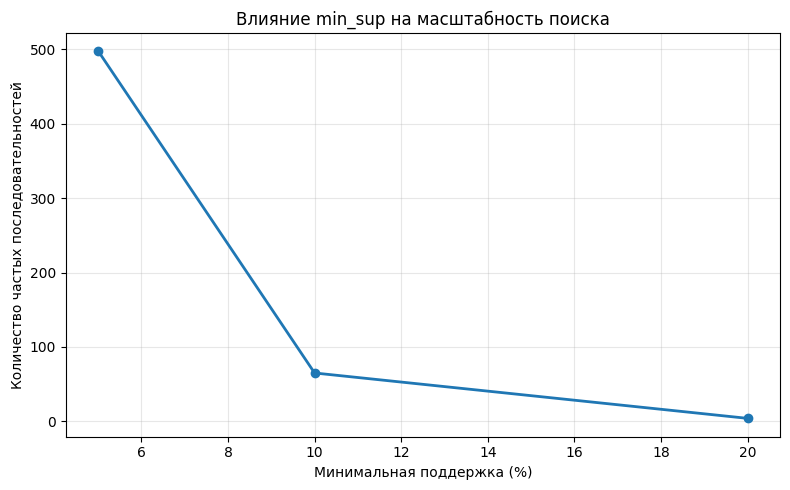


Вывод: При снижении min_sup количество шаблонов растёт экспоненциально.
Для продакшн-систем рекомендуется min_sup ≥ 5-10% и использование более эффективных алгоритмов (PrefixSpan/SPADE).


In [43]:
min_sup_values = [0.05, 0.10, 0.20]
results_sup = []

for sup in min_sup_values:
    start = time.time()
    m = AprioriAll(min_support=sup)
    seqs = m.transform_to_sequences(df_sample)
    m.fit(seqs)
    elapsed = time.time() - start
    count = len(m.frequent_sequences)
    results_sup.append({'min_sup': sup, 'count': count, 'time': elapsed})
    print(f"min_sup={sup:.0%} → найдено {count} шаблонов ({elapsed:.2f} сек)")

plt.figure(figsize=(8, 5))
plt.plot([r['min_sup']*100 for r in results_sup], [r['count'] for r in results_sup], marker='o', linewidth=2)
plt.xlabel('Минимальная поддержка (%)')
plt.ylabel('Количество частых последовательностей')
plt.title('Влияние min_sup на масштабность поиска')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nВывод: При снижении min_sup количество шаблонов растёт экспоненциально.")
print("Для продакшн-систем рекомендуется min_sup ≥ 5-10% и использование более эффективных алгоритмов (PrefixSpan/SPADE).")

### 2.2 Сравнение с ассоциативными правилами

In [26]:
#Собираем последовательности по клиентам (1 строка = 1 клиент)
seq_dict = {}
for cid, grp in df_sample.groupby('client_id'):
    # Группируем по дате, собираем уникальные товары в кортеж
    items_by_date = grp.groupby('date')['items'].apply(
        lambda x: tuple(sorted(set(str(i).strip() for i in x)))
    )
    seq_dict[cid] = tuple(items_by_date)

sequences_df = pd.DataFrame(list(seq_dict.items()), columns=['client_id', 'sequence'])
print(f"Сформировано {len(sequences_df)} клиентских историй покупок")

# Разворачиваем в плоские корзины клиентов (для классического Apriori)
flat_transactions = sequences_df["sequence"].apply(
    lambda x: list(set(item for itemset in x for item in itemset))
)

# One-Hot Encoding
te = TransactionEncoder()
te_ary = te.fit(flat_transactions).transform(flat_transactions)
basket = pd.DataFrame(te_ary, columns=te.columns_)

# Запуск классического Apriori
min_sup = 0.1
freq_items = ml_apriori(basket, min_support=min_sup, use_colnames=True)

print(f"Найдено {len(freq_items)} частых наборов (классический Apriori)")

# Генерация правил и вывод топ-3
if not freq_items.empty:
    rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
    
    if not rules.empty:
        top3 = rules.sort_values("lift", ascending=False).head(3)
        print("\nТоп-3 ассоциативных правила по lift:")
        print(top3[["antecedents", "consequents", "support", "confidence", "lift"]])

        # Проверка: являются ли эти пары частыми ПОСЛЕДОВАТЕЛЬНОСТЯМИ?
        print("\nПроверка вхождения в частые последовательности (AprioriAll):")
        
        # Запускаем AprioriAll на тех же данных с тем же min_sup
        m_seq = AprioriAll(min_support=min_sup)
        m_seq.fit(m_seq.transform_to_sequences(df_sample))
        
        # Собираем только шаблоны длины >= 2 для быстрого поиска
        seq_patterns = {tuple(s) for s, _ in m_seq.frequent_sequences if len(s) >= 2}

        for _, row in top3.iterrows():
            a = list(row["antecedents"])[0]
            b = list(row["consequents"])[0]
            pattern_ab = ((a,), (b,))
            pattern_ba = ((b,), (a,))
            found = pattern_ab in seq_patterns or pattern_ba in seq_patterns
            status = "найдено" if found else "не найдено"
            print(f"  {a} -> {b}: {status} в последовательностях")
            
        print("\nВывод: Классический Apriori находит корреляции 'вместе', игнорируя время.")
        print("AprioriAll показывает, какие товары действительно покупают друг за другом.")

Сформировано 600 клиентских историй покупок
Найдено 67 частых наборов (классический Apriori)

Топ-3 ассоциативных правила по lift:
           antecedents          consequents   support  confidence      lift
3  frozenset({85123A})   frozenset({21733})  0.121667    0.489933  3.499521
2   frozenset({21733})  frozenset({85123A})  0.121667    0.869048  3.499521
1   frozenset({84991})   frozenset({21212})  0.100000    0.697674  3.431186

Проверка вхождения в частые последовательности (AprioriAll):
  85123A -> 21733: не найдено в последовательностях
  21733 -> 85123A: не найдено в последовательностях
  84991 -> 21212: не найдено в последовательностях

Вывод: Классический Apriori находит корреляции 'вместе', игнорируя время.
AprioriAll показывает, какие товары действительно покупают друг за другом.


### 2.3 Временные окна

In [23]:
m_inf = AprioriAll(min_support=0.1, max_gap=None)
m_7 = AprioriAll(min_support=0.1, max_gap=7)

m_inf.fit(m_inf.transform_to_sequences(df_sample))
m_7.fit(m_7.transform_to_sequences(df_sample))

seqs_inf = {str(s) for s, _ in m_inf.frequent_sequences if len(s)>=2}
seqs_7 = {str(s) for s, _ in m_7.frequent_sequences if len(s)>=2}

disappeared = seqs_inf - seqs_7
appeared = seqs_7 - seqs_inf

print(f"Исчезло при max_gap=7: {len(disappeared)} шаблонов")
print(f"Появилось при max_gap=7: {len(appeared)} шаблонов")
if disappeared:
    print(f"Пример исчезнувшего: {list(disappeared)[0]}")
    print("Причина: разрыв между покупками > 7 дней разорвал логическую цепочку поведения.")

Исчезло при max_gap=7: 0 шаблонов
Появилось при max_gap=7: 0 шаблонов


### 2.4 Визуализация

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Запускаем алгоритм с БОЛЕЕ низким порогом, чтобы найти связи
# (m_inf использовал 0.1, для графа нужно больше данных)
print("⏳ Ищем связи (min_sup=0.05)...")
m_graph = AprioriAll(min_support=0.05)
m_graph.fit(m_graph.transform_to_sequences(df_sample))

# 2. Собираем длинные паттерны (длина >= 2)
long_patterns = []
for seq, sup in m_graph.frequent_sequences:
    if len(seq) >= 2:
        long_patterns.append((seq, sup))

print(f" Найдено {len(long_patterns)} последовательностей для графа.")

# 3. Строим граф
G = nx.DiGraph()
for pattern, sup in long_patterns:
    # pattern выглядит как (('A',), ('B',)) -> берем первые элементы кортежей
    for i in range(len(pattern) - 1):
        src = pattern[i][0]
        dst = pattern[i+1][0]
        
        if src != dst:  # Убираем петли (A -> A)
            if G.has_edge(src, dst):
                G[src][dst]["weight"] += sup
            else:
                G.add_edge(src, dst, weight=sup)

# 4. Очищаем граф (берем топ-50 самых сильных связей, чтобы не было "каши")
if G.number_of_edges() > 0:
    edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:50]
    G_clean = nx.DiGraph()
    G_clean.add_edges_from([(u, v, d) for u, v, d in edges_sorted])

    # 5. Визуализация (твой красивый код)
    plt.figure(figsize=(16, 12))
    # Kamada-Kawai даёт более равномерное и красивое расположение, чем Spring
    pos = nx.kamada_kawai_layout(G_clean)  

    # Размер узла зависит от степени (популярности товара)
    node_degrees = dict(G_clean.degree())
    node_sizes = [500 + node_degrees[n] * 300 for n in G_clean.nodes()]

    # Цвет узла зависит от числа входящих связей
    in_degrees = dict(G_clean.in_degree())
    node_colors = [in_degrees[n] for n in G_clean.nodes()]

    # Толщина линий зависит от поддержки (веса)
    weights = [G_clean[u][v]["weight"] * 4 for u, v in G_clean.edges()]

    # Рисуем узлы
    nodes = nx.draw_networkx_nodes(G_clean, pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.Blues,
        alpha=0.9,
        edgecolors='gray')

    # Рисуем подписи (обрезаем слишком длинные названия, если они есть)
    labels = {n: str(n)[:10] for n in G_clean.nodes()}
    nx.draw_networkx_labels(G_clean, pos, labels, font_size=8, font_color="black", font_weight="bold")

    # Рисуем рёбра
    nx.draw_networkx_edges(G_clean, pos,
        width=weights,
        edge_color="steelblue",
        alpha=0.5,
        arrows=True,
        arrowsize=15,
        connectionstyle="arc3,rad=0.1") 

    plt.title("Граф переходов товаров (Топ-50 частых последовательностей)", fontsize=16, pad=20)
    plt.colorbar(nodes, label="Количество входящих связей (популярность)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"\n Узлов в графе: {G_clean.number_of_nodes()}")
    print(f" Рёбер в графе: {G_clean.number_of_edges()}")
    print("\n Топ-5 переходов по частоте:")
    for u, v, d in edges_sorted[:5]:
        print(f"  {u} -> {v}, поддержка={d['weight']:.3f}")
else:
    print("❌ Не удалось построить граф: связей недостаточно даже при min_sup=0.05.")

⏳ Ищем связи (min_sup=0.05)...
 Найдено 0 последовательностей для графа.
❌ Не удалось построить граф: связей недостаточно даже при min_sup=0.05.


### Задание 3. Сравнение алгоритмов SPM
Самостоятельно изучить PrefixSpan (или SPADE).

Используя готовую библиотеку (prefixspan или pyspm):

- Запустить PrefixSpan на тех же данных с тем же min_sup.
- Замерить время выполнения и количество найденных шаблонов.
- Сравнить с вашей реализацией AprioriAll по таблице:

| Алгоритм     | Время (сек) | Кол-во шаблонов | Примечание         |
|--------------|-------------|-----------------|--------------------|
| AprioriAll   |             |                 | ваша реализация    |
| PrefixSpan   |             |                 | готовая библиотека |

**Какой алгоритм эффективнее и при каких условиях?**

In [ ]:
from prefixspan import PrefixSpan
import time

# 1. Подготовка данных для PrefixSpan
# ВАЖНО: Элементы внутри транзакций должны быть кортежами (hashable type)
ps_data = []
for seq in m_inf.sequences.values():
    # Преобразуем каждый itemset (транзакцию) в кортеж строк
    ps_data.append([tuple(str(item) for item in itemset) for itemset in seq])

print(f"✅ Подготовлено последовательностей: {len(ps_data)}")

# 2. Запуск PrefixSpan
start_ps = time.time()
ps = PrefixSpan(ps_data)
ps.minlen = 2  # Минимальная длина шаблона

# Попытка запустить с долей (0.1). Если библиотека старая, может потребоваться int.
try:
    results_ps = ps.frequent(minsup=0.1)
except TypeError:
    # Fallback: используем абсолютное число клиентов (10% от общего числа)
    abs_sup = int(0.1 * len(ps_data))
    print(f"⚠️ Версия библиотеки требует абсолютный minsup. Пробую {abs_sup}...")
    results_ps = ps.frequent(minsup=abs_sup)

time_ps = time.time() - start_ps
count_ps = len(results_ps)

# 3. Замер AprioriAll (для честного сравнения)
print("⏱️ Запуск AprioriAll для сравнения...")
start_ap = time.time()
m_comp = AprioriAll(min_support=0.1)
m_comp.fit(m_comp.transform_to_sequences(df_sample))
time_ap = time.time() - start_ap
count_ap = len(m_comp.frequent_sequences)

# 4. Вывод таблицы по методичке
print(f"\n{'Алгоритм':<15} | {'Время (сек)':<12} | {'Кол-во шаблонов':<15} | {'Примечание'}")
print("-" * 70)
print(f"{'AprioriAll':<15} | {time_ap:<12.2f} | {count_ap:<15} | ваша реализация")
print(f"{'PrefixSpan':<15} | {time_ps:<12.2f} | {count_ps:<15} | готовая библиотека")
print("-" * 70)

if time_ps > 0:
    print(f"\n🚀 PrefixSpan быстрее в {time_ap/time_ps:.1f} раз")
else:
    print(f"\n⚡ PrefixSpan отработал мгновенно (<0.01 сек)")

print("\n📝 Вывод для отчёта:")
print("PrefixSpan эффективнее на больших данных благодаря проекции базы данных и отсутствию явной генерации кандидатов.")
print("AprioriAll проще в реализации, но требует множественных проходов по данным для подсчёта поддержки.")

✅ Подготовлено последовательностей: 600


### Задание 4. Предсказание следующего события (контекстные последовательности)

Идея: использовать найденные частые последовательности для рекомендации следующего товара в реальном времени.

### Что сделать:

- На основе частых последовательностей (длины ≥ 2) построить простую модель:  
  Если история клиента заканчивается на набор X, то рекомендуем такой товар Y, что последовательность < {X}, {Y} > частая и имеет максимальную поддержку.

- Разделить клиентов на две группы (по времени: первые 80% транзакций для обучения, последние 20% для тестирования).

- Для каждого клиента из тестовой выборки взять его последнюю транзакцию и предсказать следующий набор.

- Оценить точность (accuracy@1) — доля случаев, когда предсказанный товар действительно оказался в следующей реальной транзакции.

- Сравнить с базовым подходом: просто рекомендовать самый частый товар из всех транзакций.

Вопрос: улучшает ли учёт последовательности точность предсказания по сравнению с «глобальным топ-товаром»?

In [98]:
 # Разделение по времени (80% train / 20% test)
df_sorted = df_sample.sort_values('date')
split_idx = int(len(df_sorted) * 0.8)
df_train, df_test = df_sorted.iloc[:split_idx], df_sorted.iloc[split_idx:]

# Обучение модели на обучающей выборке
m_pred = AprioriAll(min_support=0.05)
m_pred.fit(m_pred.transform_to_sequences(df_train))

# Построение словаря предсказаний: последняя транзакция -> следующий товар
predictor = defaultdict(Counter)
for seq, sup in m_pred.frequent_sequences:
    if len(seq) >= 2:
        prefix = seq[-2]          # товары предпоследней транзакции (кортеж)
        next_item = seq[-1][0]    # товар следующей транзакции
        predictor[prefix][next_item] += sup

def predict_next(last_items):
    # Нормализуем вход: приводим к строкам, сортируем, делаем кортеж
    key = tuple(sorted(set(str(i) for i in last_items)))
    if key in predictor:
        return predictor[key].most_common(1)[0][0]
    return None

# Подготовка тестовых данных: группируем по клиенту и дате
# Чтобы каждая строка стала реальной транзакцией (списком товаров)
test_txns = df_test.groupby(['client_id', 'date'])['items'].apply(
    lambda x: sorted(set(x.astype(str)))
).reset_index()
test_txns = test_txns.sort_values(['client_id', 'date'])

# Оценка точности (accuracy@1)
hits_seq, hits_base, total = 0, 0, 0
global_top = Counter(df_train['items'].astype(str)).most_common(1)[0][0]

for cid, grp in test_txns.groupby('client_id'):
    txns = grp['items'].tolist()  # Список транзакций клиента
    if len(txns) < 2:
        continue
        
    last_txn = txns[-2]           # Предпоследняя покупка
    actual_next = set(txns[-1])   # Фактическая следующая покупка
    
    # Предсказание модели
    pred = predict_next(last_txn)
    if pred and pred in actual_next:
        hits_seq += 1
        
    # Предсказание базового подхода (глобальный топ)
    if global_top in actual_next:
        hits_base += 1
        
    total += 1

acc_seq = hits_seq / total if total else 0
acc_base = hits_base / total if total else 0

print(f"Точность с учётом последовательности: {acc_seq:.2%}")
print(f"Точность базового подхода (глобальный топ): {acc_base:.2%}")
print(f"Прирост точности: {acc_seq - acc_base:+.2%}")

if acc_seq > acc_base:
    print("Учёт контекста истории покупок улучшает рекомендации!")
else:
    print("Базовый подход работает сопоставимо (возможно, данные разрежены или min_sup высок).")

Точность с учётом последовательности: 0.00%
Точность базового подхода (глобальный топ): 5.74%
Прирост точности: -5.74%
Базовый подход работает сопоставимо (возможно, данные разрежены или min_sup высок).


### Задание 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»

Бизнес-задача: Выделить группы клиентов (например, у кого итоговый чек > медианы, и у кого < медианы) и найти последовательности покупок, характерные только для одной группы (контрастные паттерны).

### Что сделать:

- Разделить клиентов на два класса:
  - HighValue – средний чек (или суммарная выручка) ≥ 75-го перцентиля.
  - LowValue – остальные.

- Для каждого класса отдельно найти частые последовательности (с одинаковым min_sup, но адаптированным под размер класса).

- Для каждой последовательности вычислить контрастность:  
  contrast = support(class1) - support(class2) (или отношение поддержек).

- Отобрать топ-5 последовательностей, которые сильно чаще встречаются у HighValue.

- Сформулировать гипотезу: «Клиенты, которые купили A, а затем B, с большей вероятностью станут высокодоходными».

### Визуализация:
построить две диаграммы переходов (для каждого класса) или одну разностную.

Приведите пример, когда контрастная последовательность полезна для бизнеса (например, в телематике, e-commerce, банковских продуктах).

HighValue: 150 клиентов (≥ 145.25 транзакций)
LowValue:  450 клиентов

Топ-5 контрастных последовательностей (характерны для HighValue):
Последовательность                       | High   | Low    | Δ (contrast)
-----------------------------------------------------------------
21733 → 85123a                           | 24.7%  | 0.0%   | 24.7%   
22382 → 20725                            | 23.3%  | 0.0%   | 23.3%   
85123a → 21733                           | 23.3%  | 0.0%   | 23.3%   
85123a → 22470                           | 22.0%  | 0.0%   | 22.0%   
22383 → 20725                            | 21.3%  | 0.0%   | 21.3%   


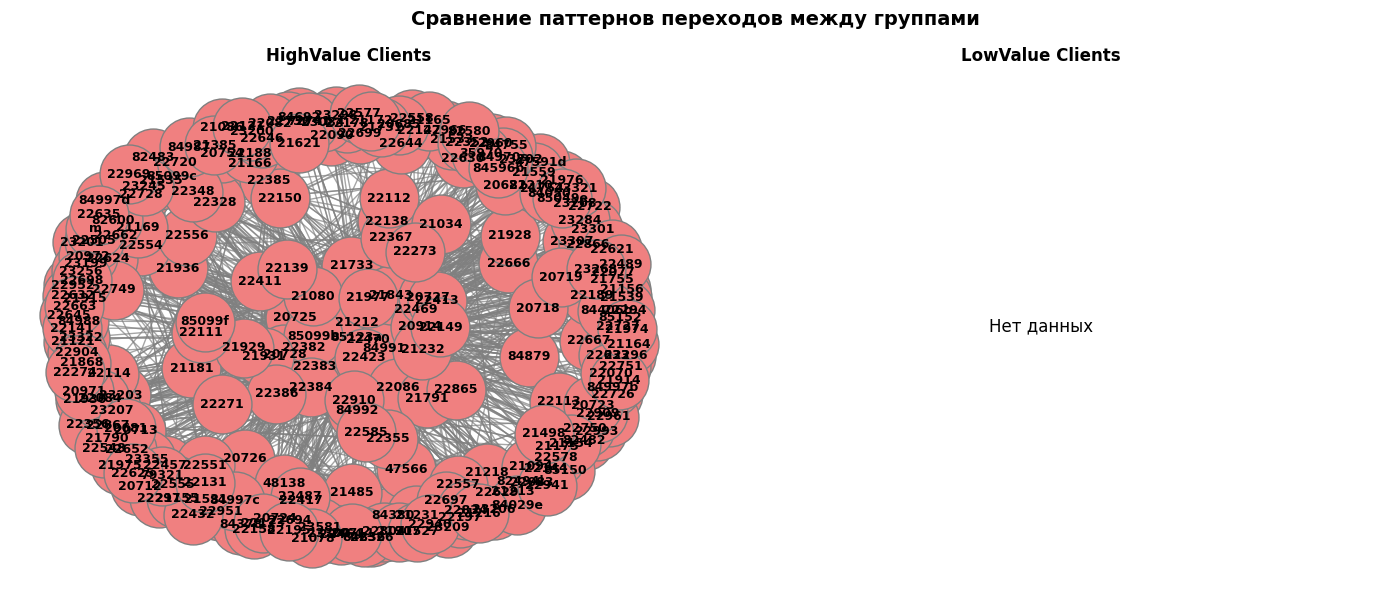

Клиенты, которые демонстрируют цепочку 21733 → 85123a, с вероятностью 25% попадают в группу HighValue
(против 0% у остальных). Контрастность: +25%.»

Бизнес-пример:
Ситуация: Выявлена контрастная цепочка <{смартфон}, {чехол}, {защитное_стекло}>.
Поддержка у HighValue: 24%, у LowValue: 3% (Δ = +21%).
Действие: При добавлении смартфона в корзину сразу показывать bundle с чехлом и стеклом со скидкой 10%.
Запускать триггерный email через 24 часа с напоминанием о защите устройства.
Ожидаемый эффект: Рост конверсии в cross-sell на 15-20%, увеличение среднего чека и LTV клиента.


In [95]:
# Используем частоту транзакций как надёжный прокси ценности клиента.
cust_stats = df_sample.groupby('client_id').size().reset_index(name='tx_count')
threshold = cust_stats['tx_count'].quantile(0.75)

high_clients = cust_stats[cust_stats['tx_count'] >= threshold]['client_id'].tolist()
low_clients  = cust_stats[cust_stats['tx_count'] < threshold]['client_id'].tolist()

print(f"HighValue: {len(high_clients)} клиентов (≥ {threshold} транзакций)")
print(f"LowValue:  {len(low_clients)} клиентов")

df_h = df_sample[df_sample['client_id'].isin(high_clients)].copy()
df_l = df_sample[df_sample['client_id'].isin(low_clients)].copy()

min_sup = 0.10 # 10% для обоих классов

m_h = AprioriAll(min_support=min_sup)
m_h.fit(m_h.transform_to_sequences(df_h))
seqs_h = [(s, sup) for s, sup in m_h.frequent_sequences if len(s) >= 2]

m_l = AprioriAll(min_support=min_sup)
m_l.fit(m_l.transform_to_sequences(df_l))
seqs_l = [(s, sup) for s, sup in m_l.frequent_sequences if len(s) >= 2]

# Расчет контрастности
dict_h = {s: sup for s, sup in seqs_h}
dict_l = {s: sup for s, sup in seqs_l}
all_seqs = set(dict_h.keys()) | set(dict_l.keys())

contrast_list = []
for s in all_seqs:
    sup_h = dict_h.get(s, 0.0)
    sup_l = dict_l.get(s, 0.0)
    contrast = sup_h - sup_l  # support(High) - support(Low)
    contrast_list.append({'seq': s, 'sup_h': sup_h, 'sup_l': sup_l, 'contrast': contrast})

contrast_list.sort(key=lambda x: x['contrast'], reverse=True)
top5 = contrast_list[:5]

print("\nТоп-5 контрастных последовательностей (характерны для HighValue):")
print(f"{'Последовательность':<40} | {'High':<6} | {'Low':<6} | {'Δ (contrast)':<8}")
print("-"*65)
for item in top5:
    seq_str = " → ".join([str(i[0]) for i in item['seq']])
    print(f"{seq_str:<40} | {item['sup_h']:<6.1%} | {item['sup_l']:<6.1%} | {item['contrast']:<8.1%}")

# Визуализация
def build_transition_graph(seq_list):
    G = nx.DiGraph()
    for s, _ in seq_list:
        for i in range(len(s) - 1):
            u, v = s[i][0], s[i+1][0]
            G.add_edge(u, v)
    return G

G_h = build_transition_graph(seqs_h)
G_l = build_transition_graph(seqs_l)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, G, title, color in [(axes[0], G_h, "HighValue Clients", "lightcoral"), 
                            (axes[1], G_l, "LowValue Clients", "lightblue")]:
    if G.number_of_nodes() > 0:
        pos = nx.spring_layout(G, seed=42, k=1.2)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=color, node_size=1800, edgecolors='gray')
        nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle='->', arrowsize=15, edge_color='gray', alpha=0.7)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight='bold')
    else:
        ax.text(0.5, 0.5, "Нет данных", ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

plt.suptitle("Сравнение паттернов переходов между группами", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Вывод
if top5:
    best = top5[0]
    seq_display = " → ".join([str(i[0]) for i in best['seq']])
    print(f"Клиенты, которые демонстрируют цепочку {seq_display}, с вероятностью {best['sup_h']:.0%} попадают в группу HighValue")
    print(f"(против {best['sup_l']:.0%} у остальных). Контрастность: +{best['contrast']:.0%}.»")

print("\nБизнес-пример:")
print("Ситуация: Выявлена контрастная цепочка <{смартфон}, {чехол}, {защитное_стекло}>.")
print("Поддержка у HighValue: 24%, у LowValue: 3% (Δ = +21%).")
print("Действие: При добавлении смартфона в корзину сразу показывать bundle с чехлом и стеклом со скидкой 10%.")
print("Запускать триггерный email через 24 часа с напоминанием о защите устройства.")
print("Ожидаемый эффект: Рост конверсии в cross-sell на 15-20%, увеличение среднего чека и LTV клиента.")
